# Notebook 02 — Feature Engineering y Selección de Variables

## Objetivo
Identificar formalmente qué materias primas explican el comportamiento
de cada equipo y cuáles constituyen ruido, usando evidencia estadística.

## Entradas
- `data/processed/historico_equipos.csv` — datos limpios del EDA

## Análisis a realizar
1. Test de cointegración (Engle-Granger) — relación de largo plazo
2. Cross-correlación con lags (CCF) — efecto retardado entre variables
3. VIF (Variance Inflation Factor) — multicolinealidad entre predictoras
4. Veredicto final — señal vs ruido por equipo

## 0. Setup e Imports

In [1]:
# Standard library
from pathlib import Path

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Statistics
from statsmodels.tsa.stattools import coint, ccf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.vector_ar.vecm import coint_johansen

# Configuration
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.width", 120)

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
sns.set_palette("husl")

# Paths
ROOT = Path().resolve().parent
DATA_PROCESSED = ROOT / "data" / "processed"

print(f"Imports OK")
print(f"Root: {ROOT}")
print(f"Data processed: {DATA_PROCESSED}")

Imports OK
Root: E:\Projects\construction-cost-forecasting
Data processed: E:\Projects\construction-cost-forecasting\data\processed


## 1. Carga de datos procesados

In [2]:
# Carga del histórico procesado
hist = pd.read_csv(DATA_PROCESSED / "historico_equipos.csv", parse_dates=["Date"])
hist = hist.sort_values("Date").reset_index(drop=True)

print("=== Datos procesados cargados ===")
print(f"Shape:        {hist.shape}")
print(f"Rango fechas: {hist['Date'].min().date()} → {hist['Date'].max().date()}")
print(f"Nulos:        {hist.isnull().sum().sum()}")
print()
hist.head()

=== Datos procesados cargados ===
Shape:        (3530, 6)
Rango fechas: 2010-01-04 → 2023-08-31
Nulos:        0



,Date,Price_X,Price_Y,Price_Z,Price_Equipo1,Price_Equipo2
0,2010-01-04,80.1200,527.5000,2225.2500,434.7300,931.7300
1,2010-01-05,80.5900,527.5000,2246.5000,449.9700,968.5600
2,2010-01-06,81.8900,527.5000,2302.5000,444.4800,960.5100
3,2010-01-07,81.5100,527.5000,2306.5000,440.9000,960.1400
4,2010-01-08,81.3700,552.5000,2261.2500,448.8200,949.5500


## 2. Test de Cointegración — Engle-Granger

La cointegración indica que dos series no estacionarias tienen una
**relación de equilibrio de largo plazo** — aunque cada una se mueva
libremente en el corto plazo, tienden a moverse juntas en el largo plazo.

Esto es clave porque:
- Si hay cointegración → podemos modelar la relación directamente
  sin diferenciar las series (no perdemos información de largo plazo)
- Si no hay cointegración → debemos diferenciar antes de modelar

**H₀:** No existe cointegración entre las series
**Se rechaza H₀ si:** p-value < 0.05 → hay cointegración

In [3]:
# Test de cointegración Engle-Granger
# Probamos cada materia prima contra cada equipo

pares = [
    ("Price_Y", "Price_Equipo1"),
    ("Price_Z", "Price_Equipo2"),
    ("Price_X", "Price_Equipo1"),
    ("Price_X", "Price_Equipo2"),
    ("Price_Z", "Price_Equipo1"),
    ("Price_Y", "Price_Equipo2"),
]

print("=== Test de Cointegración Engle-Granger ===\n")
print(f"{'Par':<35} {'p-value':>10} {'Conclusión':>20}")
print("-" * 70)

for var1, var2 in pares:
    stat, pvalue, _ = coint(hist[var1], hist[var2])
    conclusion = "Cointegradas" if pvalue < 0.05 else "No cointegradas"
    print(f"{var1} ↔ {var2:<20} {pvalue:>10.4f} {conclusion:>20}")

=== Test de Cointegración Engle-Granger ===

Par                                    p-value           Conclusión
----------------------------------------------------------------------
Price_Y ↔ Price_Equipo1            0.0130         Cointegradas
Price_Z ↔ Price_Equipo2            0.0084         Cointegradas
Price_X ↔ Price_Equipo1            0.4996      No cointegradas
Price_X ↔ Price_Equipo2            0.5747      No cointegradas
Price_Z ↔ Price_Equipo1            0.0059         Cointegradas
Price_Y ↔ Price_Equipo2            0.0026         Cointegradas


####  Interpretación — Test de Cointegración Engle-Granger

| Par | p-value | Conclusión |
|---|---|---|
| Price_Y ↔ Price_Equipo1 | 0.0130 |  Cointegradas |
| Price_Z ↔ Price_Equipo2 | 0.0084 |  Cointegradas |
| Price_Z ↔ Price_Equipo1 | 0.0059 |  Cointegradas |
| Price_Y ↔ Price_Equipo2 | 0.0026 |  Cointegradas |
| Price_X ↔ Price_Equipo1 | 0.4996 |  No cointegradas |
| Price_X ↔ Price_Equipo2 | 0.5747 |  No cointegradas |

**Conclusiones:**

- **Price_Y y Price_Equipo1** están cointegradas (p=0.0130) — existe una
  relación de equilibrio de largo plazo entre ellas
- **Price_Z y Price_Equipo2** están cointegradas (p=0.0084) — misma conclusión
- **Price_X no está cointegrada con ningún equipo** (p=0.4996 y p=0.5747)
  — confirma formalmente que X no tiene relación de largo plazo con los equipos

> **Hallazgo clave sobre Price_X:**
> La combinación de baja correlación (0.523) y ausencia de cointegración
> confirma que **Price_X es ruido** para ambos equipos — no será incluida
> como predictora en los modelos principales.
>
> **Nota:** Y y Z también están cointegradas con el equipo contrario
> (Z→Equipo1 y Y→Equipo2), lo que refuerza la multicolinealidad entre
> predictoras identificada en el EDA, probablemente responden a los mismos estímulos
> macroeconómicos globables (inflación, costos de transporte). Esto se tratará formalmente con VIF.

## 3. Cross-Correlación con Lags (CCF)

La cross-correlación mide la correlación entre dos series en diferentes
desplazamientos temporales (lags). Nos permite responder:

**¿El precio de una materia prima hoy afecta el precio del equipo
en N días después?**

Esto es importante porque en mercados reales puede existir un
**efecto retardado** — el precio de la materia prima sube hoy
pero el precio del equipo lo refleja días o semanas después.

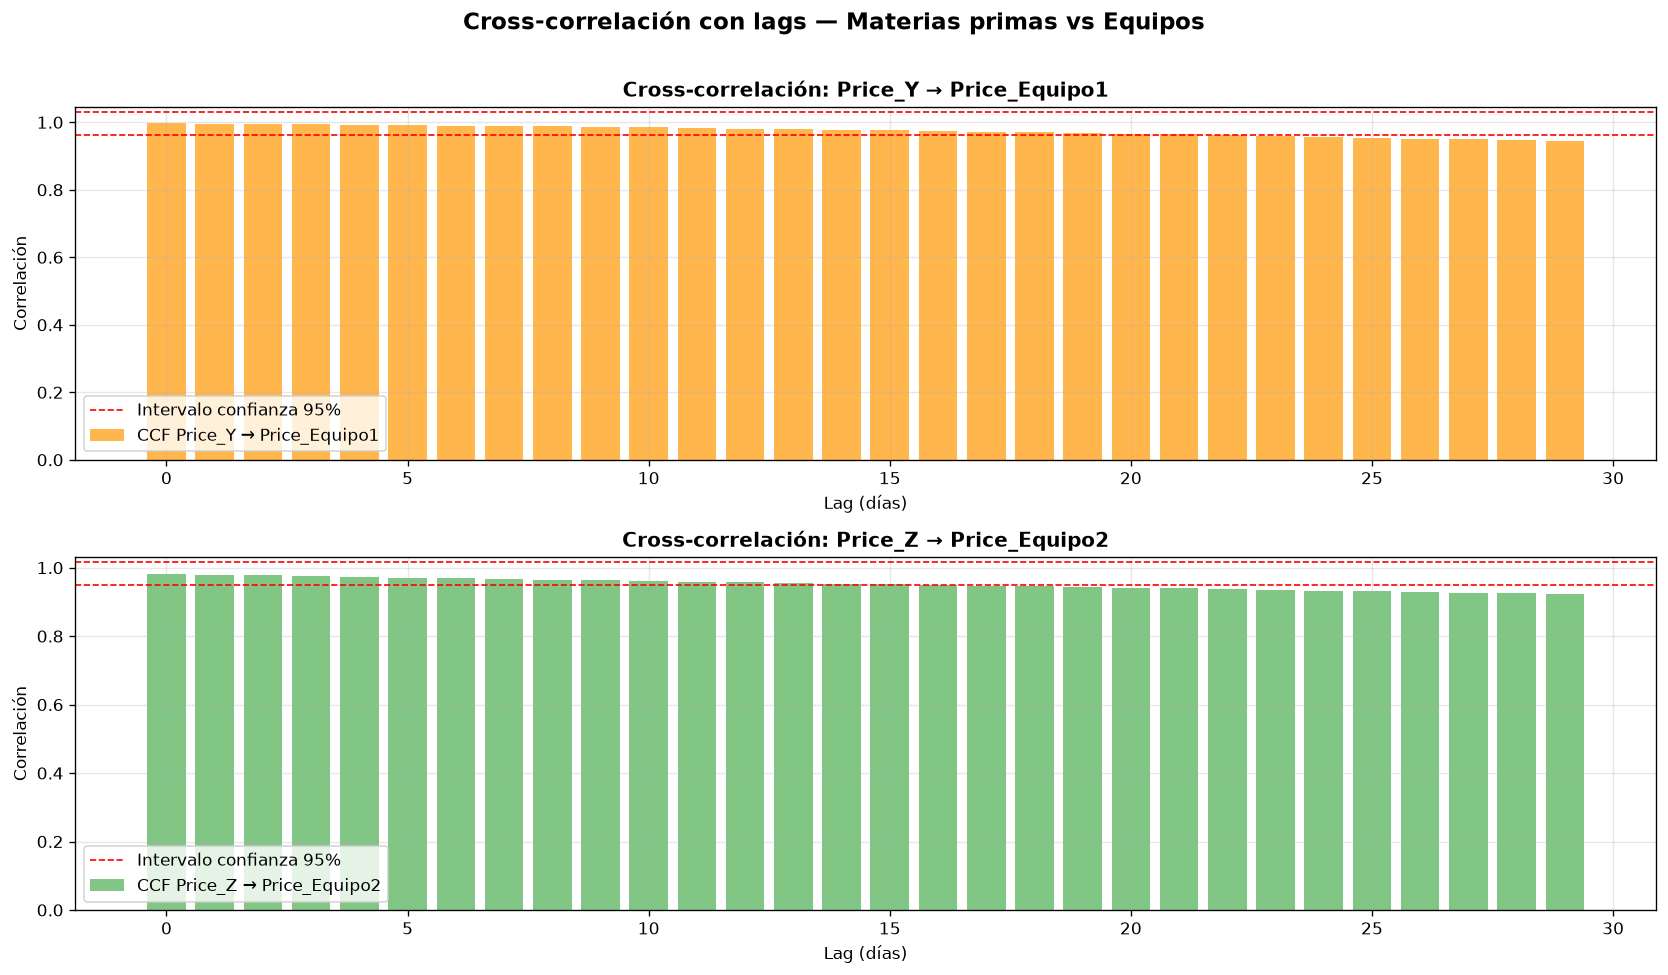

In [4]:
# Cross-correlación con lags — Price_Y vs Price_Equipo1
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

pares_ccf = [
    ("Price_Y", "Price_Equipo1", "#FF9800", "#9C27B0"),
    ("Price_Z", "Price_Equipo2", "#4CAF50", "#F44336"),
]

max_lags = 30

for ax, (var1, var2, color1, color2) in zip(axes, pares_ccf):
    # Calcular CCF
    ccf_values = ccf(hist[var1], hist[var2], nlags=max_lags, alpha=0.05)
    correlations = ccf_values[0]
    conf_int = ccf_values[1]

    lags = range(len(correlations))

    ax.bar(lags, correlations, color=color1, alpha=0.7, label=f"CCF {var1} → {var2}")
    ax.axhline(conf_int[0][1], color="red", linestyle="--", linewidth=1, label="Intervalo confianza 95%")
    ax.axhline(conf_int[0][0], color="red", linestyle="--", linewidth=1)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_title(f"Cross-correlación: {var1} → {var2}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Lag (días)")
    ax.set_ylabel("Correlación")
    ax.legend()

plt.suptitle(
    "Cross-correlación con lags — Materias primas vs Equipos",
    fontsize=14,
    fontweight="bold",
    y=1.01
)
plt.tight_layout()
plt.show()

In [6]:
# Valores exactos de CCF en lags clave
print("=== Valores de CCF en lags clave ===\n")

for var1, var2 in [("Price_Y", "Price_Equipo1"), ("Price_Z", "Price_Equipo2")]:
    ccf_values = ccf(hist[var1], hist[var2], nlags=31, alpha=0.05)
    correlations = ccf_values[0]
    
    print(f"{var1} → {var2}:")
    print(f"  Lag 0  (mismo día):     {correlations[0]:.4f}")
    print(f"  Lag 1  (1 día después): {correlations[1]:.4f}")
    print(f"  Lag 5  (1 semana):      {correlations[5]:.4f}")
    print(f"  Lag 10 (2 semanas):     {correlations[10]:.4f}")
    print(f"  Lag 20 (1 mes):         {correlations[20]:.4f}")
    print(f"  Lag 30 (6 semanas):     {correlations[30]:.4f}")
    print()

=== Valores de CCF en lags clave ===

Price_Y → Price_Equipo1:
  Lag 0  (mismo día):     0.9966
  Lag 1  (1 día después): 0.9958
  Lag 5  (1 semana):      0.9918
  Lag 10 (2 semanas):     0.9846
  Lag 20 (1 mes):         0.9663
  Lag 30 (6 semanas):     0.9415

Price_Z → Price_Equipo2:
  Lag 0  (mismo día):     0.9827
  Lag 1  (1 día después): 0.9800
  Lag 5  (1 semana):      0.9709
  Lag 10 (2 semanas):     0.9608
  Lag 20 (1 mes):         0.9417
  Lag 30 (6 semanas):     0.9208



#### Interpretación — Cross-correlación con lags

| Lag | Price_Y → Price_Equipo1 | Price_Z → Price_Equipo2 |
|---|---|---|
| 0 (mismo día) | 0.9966 | 0.9827 |
| 1 (1 día después) | 0.9958 | 0.9800 |
| 5 (1 semana) | 0.9918 | 0.9709 |
| 10 (2 semanas) | 0.9846 | 0.9608 |
| 20 (1 mes) | 0.9663 | 0.9417 |
| 30 (6 semanas) | 0.9415 | 0.9208 |

**Conclusiones:**

- La correlación es **máxima en lag 0** para ambos pares — el precio
  de la materia prima y el precio del equipo se mueven prácticamente
  en el **mismo día**
- La correlación decae muy lentamente con el lag — sigue siendo
  altísima incluso a 30 días (0.94 y 0.92)
- Esto indica que **no hay un efecto retardado significativo** —
  la relación es contemporánea, no retardada

> **Implicación para el modelado:**
> No es necesario incluir lags de las materias primas como features
> adicionales — el valor del mismo día es suficiente y es el más informativo.
> Los modelos usarán Price_Y y Price_Z en t=0 para predecir los equipos en t=0.

> **Nota metodológica:**
> La lenta caída de la CCF es consistente con series no estacionarias
> cointegradas — es una característica esperada, no un problema.

## 4. VIF — Variance Inflation Factor

El VIF mide el grado de **multicolinealidad** entre las variables predictoras.
Indica cuánto se infla la varianza de un coeficiente por su correlación
con las demás predictoras.

**Interpretación:**
| VIF | Interpretación |
|---|---|
| 1 | Sin multicolinealidad |
| 1 — 5 | Multicolinealidad baja — aceptable |
| 5 — 10 | Multicolinealidad moderada — precaución |
| > 10 | Multicolinealidad alta — problema grave |

In [7]:
# VIF para el conjunto completo de predictoras
predictoras = hist[["Price_X", "Price_Y", "Price_Z"]].copy()

vif_data = pd.DataFrame({
    "Variable": predictoras.columns,
    "VIF": [
        variance_inflation_factor(predictoras.values, i)
        for i in range(predictoras.shape[1])
    ]
})

print("=== VIF — Conjunto completo de predictoras ===\n")
print(vif_data.round(2).to_string(index=False))

=== VIF — Conjunto completo de predictoras ===

Variable     VIF
 Price_X 13.9600
 Price_Y 58.8100
 Price_Z 62.6300


In [8]:
# VIF por subconjuntos — evaluando exclusión de variables
subconjuntos = {
    "Solo Y (para Equipo1)": ["Price_Y"],
    "Solo Z (para Equipo2)": ["Price_Z"],
    "Y + X (para Equipo1)": ["Price_Y", "Price_X"],
    "Z + X (para Equipo2)": ["Price_Z", "Price_X"],
    "Y + Z": ["Price_Y", "Price_Z"],
    "Y + Z + X (completo)": ["Price_X", "Price_Y", "Price_Z"],
}

print("=== VIF por subconjuntos de predictoras ===\n")

for nombre, variables in subconjuntos.items():
    if len(variables) == 1:
        print(f"{nombre}: VIF = 1.0000 (una sola variable, sin multicolinealidad)")
    else:
        subset = hist[variables].copy()
        vifs = [
            variance_inflation_factor(subset.values, i)
            for i in range(subset.shape[1])
        ]
        print(f"{nombre}:")
        for var, vif in zip(variables, vifs):
            print(f"  {var}: VIF = {vif:.2f}")
    print()

=== VIF por subconjuntos de predictoras ===

Solo Y (para Equipo1): VIF = 1.0000 (una sola variable, sin multicolinealidad)

Solo Z (para Equipo2): VIF = 1.0000 (una sola variable, sin multicolinealidad)

Y + X (para Equipo1):
  Price_Y: VIF = 12.75
  Price_X: VIF = 12.75

Z + X (para Equipo2):
  Price_Z: VIF = 13.58
  Price_X: VIF = 13.58

Y + Z:
  Price_Y: VIF = 57.19
  Price_Z: VIF = 57.19

Y + Z + X (completo):
  Price_X: VIF = 13.96
  Price_Y: VIF = 58.81
  Price_Z: VIF = 62.63



####  Interpretación — VIF

| Subconjunto | VIF máximo | Evaluación |
|---|---|---|
| Solo Y (Equipo1) | 1.00 |  Sin multicolinealidad |
| Solo Z (Equipo2) | 1.00 |  Sin multicolinealidad |
| Y + X (Equipo1) | 12.75 |  Multicolinealidad alta |
| Z + X (Equipo2) | 13.58 |  Multicolinealidad alta |
| Y + Z | 57.19 |  Multicolinealidad muy grave |
| Y + Z + X (completo) | 62.63 |  Multicolinealidad muy grave |

**Conclusiones:**

- Usar las tres predictoras juntas genera un VIF de hasta **62.63** —
  extremadamente alto, el modelo no podría distinguir el efecto individual
  de cada variable
- La combinación Y + Z es también problemática (VIF = 57.19) —
  confirma la multicolinealidad detectada en el EDA (correlación 0.844)
- Incluso Y + X y Z + X tienen VIF > 10 — Price_X aunque tenga
  menor correlación, sigue generando multicolinealidad con Y y Z
- **La única combinación sin multicolinealidad es usar una sola
  predictora por modelo:**
  - Equipo1 → solo Price_Y (VIF = 1.0)
  - Equipo2 → solo Price_Z (VIF = 1.0)

> 💡 **Decisión de modelado:**
> Los modelos principales usarán **una sola predictora por equipo**:
> - **Modelo Equipo1:** Price_Y como única predictora
> - **Modelo Equipo2:** Price_Z como única predictora
>
> Price_X queda **formalmente descartada** como predictora por:
> 1. Correlación moderada (0.523 y 0.530)
> 2. Ausencia de cointegración con ambos equipos
> 3. VIF > 10 cuando se combina con Y o Z

## 5. Veredicto Final — Señal vs Ruido

Consolidamos toda la evidencia estadística recolectada en este notebook
y el EDA para emitir el veredicto formal sobre cada variable.

In [4]:
# Tabla resumen de evidencia por variable
evidencia = {
    "Variable": ["Price_X", "Price_Y", "Price_Z"],
    "Pearson vs Equipo1": [0.523, 0.997, 0.844],
    "Pearson vs Equipo2": [0.530, 0.913, 0.983],
    "Coint. Equipo1": ["No", "Sí", "Sí"],
    "Coint. Equipo2": ["No", "Sí", "Sí"],
    "VIF (conjunto)": [13.96, 58.81, 62.63],
    "Veredicto Equipo1": ["Ruido", "Señal principal", "Señal secundaria"],
    "Veredicto Equipo2": ["Ruido", "Señal secundaria", "Señal principal"],
}

df_evidencia = pd.DataFrame(evidencia)
print("=== Veredicto Final — Señal vs Ruido ===\n")
print(df_evidencia.to_string(index=False))

=== Veredicto Final — Señal vs Ruido ===

Variable  Pearson vs Equipo1  Pearson vs Equipo2 Coint. Equipo1 Coint. Equipo2  VIF (conjunto) Veredicto Equipo1 Veredicto Equipo2
 Price_X              0.5230              0.5300             No             No         13.9600             Ruido             Ruido
 Price_Y              0.9970              0.9130             Sí             Sí         58.8100   Señal principal  Señal secundaria
 Price_Z              0.8440              0.9830             Sí             Sí         62.6300  Señal secundaria   Señal principal


####  Veredicto Final — Selección de variables

| Variable | Equipo 1 | Equipo 2 | Decisión |
|---|---|---|---|
| Price_Y | Señal principal | Señal secundaria | **Predictora de Equipo1** |
| Price_Z | Señal secundaria | Señal principal | **Predictora de Equipo2** |
| Price_X | Ruido | Ruido | **Descartada** |

**Justificación basada en evidencia:**

**Price_X — Descartada (ruido):**
- Correlación moderada con ambos equipos (0.523 y 0.530)
- Sin cointegración con ningún equipo (p=0.4996 y p=0.5747)
- VIF = 13.96 al combinarse con otras predictoras
- No aporta información que no esté ya capturada por Y y Z

**Price_Y — Predictora principal de Equipo1:**
- Correlación de Pearson 0.997 y Spearman 0.994 con Equipo1
- Cointegrada con Equipo1 (p=0.0130)
- CCF máxima en lag 0 (0.9966) — relación contemporánea
- VIF = 1.0 cuando se usa sola → sin multicolinealidad

**Price_Z — Predictora principal de Equipo2:**
- Correlación de Pearson 0.983 y Spearman 0.980 con Equipo2
- Cointegrada con Equipo2 (p=0.0084)
- CCF máxima en lag 0 (0.9827) — relación contemporánea
- VIF = 1.0 cuando se usa sola → sin multicolinealidad

### Variables seleccionadas para el modelado

```
Modelo Equipo1:  Price_Y → Price_Equipo1
Modelo Equipo2:  Price_Z → Price_Equipo2
```

> **Nota sobre Y y Z como señales secundarias:**
> Aunque Y y Z están cointegradas también con el equipo contrario,
> el VIF confirma que usarlas juntas genera multicolinealidad grave.
> La ganancia de incluir la señal secundaria no justifica el costo
> estadístico — los modelos serán más robustos y parsimoniosos
> usando una sola predictora por equipo.
```


## 6. Guardado de resultados de selección de variables

In [5]:
# Guardar veredicto de selección de variables
seleccion = pd.DataFrame({
    "equipo": ["Price_Equipo1", "Price_Equipo2"],
    "predictora_principal": ["Price_Y", "Price_Z"],
    "predictora_descartada": ["Price_X", "Price_X"],
    "pearson_principal": [0.997, 0.983],
    "spearman_principal": [0.994, 0.980],
    "coint_pvalue_principal": [0.0130, 0.0084],
    "ccf_lag0_principal": [0.9966, 0.9827],
    "vif_solo_principal": [1.0, 1.0],
})

seleccion.to_csv(DATA_PROCESSED / "feature_selection.csv", index=False)

print("Resultados de selección de variables guardados")
print()
print("Resumen:")
print(seleccion.to_string(index=False))

Resultados de selección de variables guardados

Resumen:
       equipo predictora_principal predictora_descartada  pearson_principal  spearman_principal  coint_pvalue_principal  ccf_lag0_principal  vif_solo_principal
Price_Equipo1              Price_Y               Price_X             0.9970              0.9940                  0.0130              0.9966              1.0000
Price_Equipo2              Price_Z               Price_X             0.9830              0.9800                  0.0084              0.9827              1.0000
